In [2]:
import os
import re
import pickle as pkl
import ast
from collections import Counter
from typing import List, Tuple, Any
from tqdm import tqdm
import time

import pandas as pd
import numpy as np
import calibration as cal

import torch

from sentence_transformers import SentenceTransformer

from sklearn.metrics import brier_score_loss, roc_auc_score

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from llm_unsupervised_conf.metrics import *
from llm_unsupervised_conf.math_utils import stack_embeddings
from llm_unsupervised_conf.calibration import fit_predict_prob_models
from llm_unsupervised_conf.utils import maybe_add_verbal_conf_row, load_out_df
from llm_unsupervised_conf.plots import plot_reliability, plot_avg_and_worstcase_by_method, plot_method_comparisons
from llm_unsupervised_conf.plots import METHODS_MAP

In [4]:
def split_out_df_by_id_language_blocks(
    out_df: pd.DataFrame,
    train_lang_idx,
    test_lang_idx,
    *,
    id_col: str = "id",
    n_langs: int = 8,
    block_size: int = 125,
    add_lang_col: str | None = None,
    lang_names: list[str] | None = None,
    reset_index: bool = True,
    validate_disjoint: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split out_df into train/test by *language blocks* inferred from the original integer ids.

    Language block k corresponds to ids in:
        [k*block_size, (k+1)*block_size - 1]
    Missing rows are fine; we select by id ranges.

    Args:
        out_df: dataframe containing an `id`-like column.
        train_lang_idx/test_lang_idx: lists of block indices (0..n_langs-1).
        id_col: column name containing original ids (int-like).
        n_langs: number of language blocks.
        block_size: ids per language block (125).
        add_lang_col: if set (e.g. "lang"), adds language label per row.
        lang_names: optional list of length n_langs; used if add_lang_col is set.
        reset_index: whether to reset index in returned dfs.
        validate_disjoint: if True, asserts train/test have no overlapping ids.

    Returns:
        (train_df, test_df)
    """
    train_lang_idx = list(train_lang_idx)
    test_lang_idx  = list(test_lang_idx)

    # --- validate inputs ---
    if id_col not in out_df.columns:
        raise ValueError(f"Column {id_col!r} not found in out_df.")
    if any((not isinstance(i, int)) for i in train_lang_idx + test_lang_idx):
        raise ValueError("train_lang_idx/test_lang_idx must contain integers.")
    if any(i < 0 or i >= n_langs for i in train_lang_idx + test_lang_idx):
        raise ValueError(f"Language indices must be in [0, {n_langs-1}].")
    if set(train_lang_idx) & set(test_lang_idx):
        raise ValueError("train_lang_idx and test_lang_idx overlap.")
    if len(set(train_lang_idx)) != len(train_lang_idx) or len(set(test_lang_idx)) != len(test_lang_idx):
        raise ValueError("Duplicate language indices found in train/test lists.")
    if add_lang_col is not None and lang_names is not None and len(lang_names) != n_langs:
        raise ValueError(f"lang_names must have length {n_langs} if provided.")

    df = out_df.copy()

    # ensure integer ids (but keep original column untouched if you want)
    ids = pd.to_numeric(df[id_col], errors="coerce")
    if ids.isna().any():
        bad = df.loc[ids.isna(), id_col].head(10).tolist()
        raise ValueError(f"Non-numeric ids found in {id_col!r}, e.g. {bad}")
    ids = ids.astype(int)

    # map each row to its language block index
    df["_lang_block_idx"] = (ids // block_size).astype(int)

    # sanity: optionally flag ids outside expected range
    max_valid = n_langs * block_size - 1
    out_of_range = (ids < 0) | (ids > max_valid)
    if out_of_range.any():
        ex = df.loc[out_of_range, id_col].head(10).tolist()
        raise ValueError(
            f"Found ids outside expected range [0, {max_valid}] for n_langs={n_langs}, "
            f"block_size={block_size}. Examples: {ex}"
        )

    train_df = df[df["_lang_block_idx"].isin(train_lang_idx)].copy()
    test_df  = df[df["_lang_block_idx"].isin(test_lang_idx)].copy()

    if validate_disjoint:
        overlap = set(train_df[id_col].astype(int)) & set(test_df[id_col].astype(int))
        if overlap:
            ex = sorted(list(overlap))[:10]
            raise ValueError(f"Train/test overlap on {len(overlap)} ids (e.g. {ex}).")

    if add_lang_col is not None:
        if lang_names is None:
            train_df[add_lang_col] = train_df["_lang_block_idx"]
            test_df[add_lang_col]  = test_df["_lang_block_idx"]
        else:
            mapping = {i: lang_names[i] for i in range(n_langs)}
            train_df[add_lang_col] = train_df["_lang_block_idx"].map(mapping)
            test_df[add_lang_col]  = test_df["_lang_block_idx"].map(mapping)

    # clean up helper col
    train_df.drop(columns=["_lang_block_idx"], inplace=True)
    test_df.drop(columns=["_lang_block_idx"], inplace=True)

    if reset_index:
        train_df = train_df.reset_index(drop=True)
        test_df  = test_df.reset_index(drop=True)

    return train_df, test_df


def run_exp(
    dataset,
    model,
    n=1000,
    k_train=100,
    temp_train=0.7,
    temp_test=0.6,
    prob_models = ["ridge_clip","split_isotonic_on_ridge","split_isotonic_on_ridge_nrt"],
    include_verbal_conf=True,
    random_state=42,
    n_bins=12,
    embedding_text="question_response",
    drop_bad_rows=True,
    verbose=False,
    language_split=1
):
    """
    prob_models controls which embedding->prob models to include.
    Example:
      prob_models=["ridge_clip","ridge_logit","hgb_logit","mlp_logit","isotonic_on_ridge"]
    """

    model_name = model.split("/")[-1]

    out_df, df_save_path = load_out_df(dataset, model_name, n, temp_train, k_train, temp_test, embedding_text, drop_bad_rows)

    # --------------------
    # Split
    # --------------------
    train_lang_idx = LANGUAGE_SPLITS[language_split]["train_lang_idx"]
    test_lang_idx  = LANGUAGE_SPLITS[language_split]["test_lang_idx"]

    train_df, test_df = split_out_df_by_id_language_blocks(
        out_df,
        train_lang_idx,
        test_lang_idx,
        id_col="id",
        add_lang_col="lang_idx",  # or "lang" with lang_names below
    )

    X_train = stack_embeddings(train_df, "embeddings")
    y_train = train_df["consistency"].astype(np.float32).to_numpy()  # target in [0,1]

    X_test = stack_embeddings(test_df, "embeddings")

    # These are for evaluation (your core metrics are vs correctness)
    con_scores = test_df["consistency"].to_numpy(dtype=float)
    correct = test_df["correct"].to_numpy(dtype=int)

    logprobs = test_df["avg_logprobs"].to_numpy(dtype=float)
    ans_logprobs = test_df["ans_logprobs"].to_numpy(dtype=float)
    lp = np.exp(logprobs)
    alp = np.exp(ans_logprobs)

    if verbose:
        print(f"Results: (accuracy={correct.mean():.4f})")

    def metric_row(name, scores, correct, n_bins):
        return [
            name,
            get_ece1(scores, correct, n_bins=n_bins),
            get_ece2(scores, correct, n_bins=n_bins),
            get_mce(scores, correct, n_bins=n_bins),
            get_nll(scores, correct),
            brier_score_loss(correct, scores),
            roc_auc_score(correct, scores),
        ]
    
    
    score_sources = {
        "logprob": lp,
        "ans_logprob": alp,
        "oracle_sc": con_scores,
    }
    
    rows = [metric_row(name, scores, correct, n_bins) for name, scores in score_sources.items()]


    # --------------------
    # Embedding->prob models
    # --------------------
    prob_models = list(prob_models) if prob_models is not None else []
    preds = fit_predict_prob_models(
        X_train=X_train,
        y_train_prob=y_train,
        X_test=X_test,
        methods=prob_models,
        random_state=random_state,
    )

    for method_name, pred_probs in preds.items():
        rows.append(metric_row(method_name, pred_probs, correct, n_bins))

    # --------------------
    # Optional: verbal confidence
    # --------------------
    vc_scores = None
    if include_verbal_conf:
        rows, vc_scores = maybe_add_verbal_conf_row(rows, df_save_path, test_df, correct, stem_idx=6)

    # --------------------
    # Pack + display
    # --------------------
    exp_df = pd.DataFrame(rows, columns=["Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC"])
    exp_df["Model"] = model
    exp_df["Dataset"] = dataset
    exp_df["Accuracy"] = float(correct.mean())
    exp_df = exp_df[["Model", "Dataset", "Method", "ECE1", "ECE2", "MCE", "NLL", "Brier", "AUROC", "Accuracy"]]

    # if verbose or random_state == 0:
    #     display(exp_df)

    return exp_df


In [5]:
def run_all_exps(models, language_split=1, seed=42):

    dataset="polymath"

    full_df = []
    
    # print(f"[status] running {dataset}")
    start_time = time.time()

    for model in models:
        # print(f"[status] running {model}")
        df = run_exp(
            dataset=dataset,
            model=model,
            random_state=seed,
            language_split=language_split
        )
        df["seed"] = seed
        full_df.append(df)
    print("--- %s seconds ---" % (time.time() - start_time))
    
    full_df = pd.concat(full_df)

    # display(full_df.head(5))

    return full_df

In [16]:
OUR_METHOD = "split_isotonic_on_ridge_nrt"

In [17]:
LANGUAGE_SPLITS = {
    1: {
        "train_lang_idx": [0,1,2,3], # Latin 1
        "test_lang_idx": [4,5,6,7]
    },
    2: {
        "train_lang_idx": [4,5,6,7], # Latin 2
        "test_lang_idx": [0,1,2,3]
    },
    3: {
        "train_lang_idx": [1,2,3,4], # Romance 1
        "test_lang_idx": [0,5,6,7]
    },
    4: {
        "train_lang_idx": [0,5,6,7], # Romance 2
        "test_lang_idx": [1,2,3,4]
    },
    5: {
        "train_lang_idx": [0,1,2,5], # HR 1
        "test_lang_idx": [3,4,6,7]
    },
    6: {
        "train_lang_idx": [3,4,6,7], # HR 2
        "test_lang_idx": [0,1,2,5]
    },
    7: {
        "train_lang_idx": [0,1,5,6], # Scripts 1
        "test_lang_idx": [2,3,4,7]
    },
    8: {
        "train_lang_idx": [2,3,4,7], # Scripts 2
        "test_lang_idx": [0,1,5,6]
    },
}

DEFAULT_POLYMATH_LANGS = ["en", "es", "fr", "pt", "it", "ru", "ar", "id"]

train_split_strs = {}
test_split_strs = {}

show_strs = {}

for k, v in LANGUAGE_SPLITS.items():
    train_langs = [DEFAULT_POLYMATH_LANGS[i] for i in LANGUAGE_SPLITS[k]["train_lang_idx"]]
    train_split_strs[k] = "_".join(train_langs)
    
    test_langs = [DEFAULT_POLYMATH_LANGS[i] for i in LANGUAGE_SPLITS[k]["test_lang_idx"]]
    test_split_strs[k] = "_".join(test_langs)

    print(k, train_split_strs[k], "-->", test_split_strs[k])

    for lang_str in [train_split_strs[k], test_split_strs[k]]:
        if lang_str not in show_strs:
            show_strs[lang_str] = lang_str.replace("_", ", ").upper()

1 en_es_fr_pt --> it_ru_ar_id
2 it_ru_ar_id --> en_es_fr_pt
3 es_fr_pt_it --> en_ru_ar_id
4 en_ru_ar_id --> es_fr_pt_it
5 en_es_fr_ru --> pt_it_ar_id
6 pt_it_ar_id --> en_es_fr_ru
7 en_es_ru_ar --> fr_pt_it_id
8 fr_pt_it_id --> en_es_ru_ar


In [18]:
def run_language_split(models, seed, split_idx):
    full_df = run_all_exps(models, language_split=split_idx, seed=seed)

    datasets = ["polymath"]
    
    full_df = full_df[(full_df["Model"].isin(models)) & (full_df["Dataset"].isin(datasets))]

    show_cols = ["Method", "ECE1", "ECE2", "MCE", "Brier", "AUROC"]

    grouped_df = full_df[show_cols+["Model", "Dataset"]].groupby(["Model", "Dataset", "Method"]).mean().reset_index()

    print("AVERAGE")
    display(
        full_df[show_cols].groupby(["Method"]).mean().sort_values(["ECE2"])
    )
    print("WORST")
    display(
        grouped_df[show_cols[:-1]].groupby(["Method"]).max().sort_values(["ECE2"])
    )

    target_metric = "ECE2"

    train_langs = [DEFAULT_POLYMATH_LANGS[l_idx] for l_idx in LANGUAGE_SPLITS[split_idx]["train_lang_idx"]]
    test_langs = [DEFAULT_POLYMATH_LANGS[l_idx] for l_idx in LANGUAGE_SPLITS[split_idx]["test_lang_idx"]]

    mean_target_metric = grouped_df[show_cols].groupby(["Method"]).mean().reset_index()[["Method", target_metric]]
    max_target_metric = grouped_df[show_cols].groupby(["Method"]).max().reset_index()[["Method", target_metric]]
    
    return_df = pd.DataFrame()
    return_df["method"] = mean_target_metric["Method"]
    return_df["avg"] = mean_target_metric[target_metric]
    return_df["worst"] = max_target_metric[target_metric]
    
    return_df["train_langs"] = "_".join(train_langs)
    return_df["test_langs"] = "_".join(test_langs)
    return_df["lang_split"] = split_idx

    display(return_df)

    # plot_avg_and_worstcase_by_method(
    #     grouped_df,
    #     metrics=("ECE1", "ECE2", "MCE", "Brier", "AUROC"),
    #     method_order=[
    #         "verbal_conf", 
    #         "logprob", 
    #         # "ans_logprob", 
    #         OUR_METHOD
    #     ],
    #     show_values=True,
    #     figsize=(16,3)
    # )

    grouped_df["train_langs"] = "_".join(train_langs)
    grouped_df["test_langs"] = "_".join(test_langs)
    grouped_df["lang_split"] = split_idx
    
    return return_df, grouped_df


In [9]:
# models = [
#     # "Qwen/Qwen3-0.6B", 
#     "Qwen/Qwen3-1.7B", 
#     "Qwen/Qwen3-4B-Thinking-2507", 
#     "Qwen/Qwen3-8B",
#     "Qwen/Qwen3-14B",
#     # "nvidia/OpenReasoning-Nemotron-7B",
#     "nvidia/Nemotron-Cascade-8B-Thinking",
#     # "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
#     # "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
# ]

models = [
    # "Qwen/Qwen3-0.6B", 
    # "Qwen/Qwen3-1.7B", 
    "Qwen/Qwen3-4B-Thinking-2507", 
    "Qwen/Qwen3-8B",
    "Qwen/Qwen3-14B",
    "nvidia/OpenReasoning-Nemotron-7B",
    "nvidia/Nemotron-Cascade-8B-Thinking",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
]

seed = 42

In [19]:
full_df = []
full_grouped_df = []

for i in range(1, 9):
    print("-"*40)
    print(f"SPLIT {i}")
    
    df, grouped_df = run_language_split(models, seed, split_idx=i)
    
    full_df.append(df)
    full_grouped_df.append(grouped_df)
    
    print()
    print("-"*40)
    print()
    
full_df = pd.concat(full_df)
full_grouped_df = pd.concat(full_grouped_df)

----------------------------------------
SPLIT 1
--- 2.6532912254333496 seconds ---
AVERAGE


,ECE1,ECE2,MCE,Brier,AUROC
Method,,,,,
oracle_sc,0.061883,0.091860,0.228724,0.101437,0.858057
split_isotonic_on_ridge_nrt,0.088218,0.102093,0.211041,0.136127,0.704625
ridge_clip,0.104700,0.119246,0.216397,0.141072,0.722290
split_isotonic_on_ridge,0.110340,0.128773,0.257872,0.144934,0.721790
logprob,0.147631,0.160570,0.240370,0.176986,0.655463
verbal_conf,0.175431,0.196222,0.318560,0.193669,0.611021
ans_logprob,0.212028,0.265161,0.537669,0.211217,0.732873


WORST


,ECE1,ECE2,MCE,Brier
Method,,,,
oracle_sc,0.080413,0.103214,0.279318,0.183796
split_isotonic_on_ridge_nrt,0.160439,0.180086,0.378267,0.247448
ridge_clip,0.200032,0.231096,0.428945,0.256344
split_isotonic_on_ridge,0.224052,0.237376,0.410884,0.262842
verbal_conf,0.366310,0.402723,0.810811,0.387242
logprob,0.440333,0.441933,0.527318,0.422654
ans_logprob,0.577758,0.601120,0.965051,0.549194


,method,avg,worst,train_langs,test_langs,lang_split
0,ans_logprob,0.265161,0.601120,en_es_fr_pt,it_ru_ar_id,1
1,logprob,0.160570,0.441933,en_es_fr_pt,it_ru_ar_id,1
2,oracle_sc,0.091860,0.103214,en_es_fr_pt,it_ru_ar_id,1
3,ridge_clip,0.119246,0.231096,en_es_fr_pt,it_ru_ar_id,1
4,split_isotonic_on_ridge,0.128773,0.237376,en_es_fr_pt,it_ru_ar_id,1
5,split_isotonic_on_ridge_nrt,0.102093,0.180086,en_es_fr_pt,it_ru_ar_id,1
6,verbal_conf,0.196222,0.402723,en_es_fr_pt,it_ru_ar_id,1


...

,ECE1,ECE2,MCE,Brier,AUROC
Method,,,,,
split_isotonic_on_ridge,0.068330,0.082386,0.306229,0.122666,0.731490
split_isotonic_on_ridge_nrt,0.064625,0.082701,0.185230,0.121969,0.735846
ridge_clip,0.071751,0.086098,0.166045,0.122866,0.736308
oracle_sc,0.055961,0.088946,0.221971,0.086673,0.891032
logprob,0.110033,0.127022,0.223229,0.145452,0.648496
verbal_conf,0.144053,0.169180,0.306672,0.169319,0.619310
ans_logprob,0.175466,0.203575,0.342456,0.173641,0.717834


WORST


,ECE1,ECE2,MCE,Brier
Method,,,,
oracle_sc,0.079020,0.111600,0.339286,0.164733
split_isotonic_on_ridge_nrt,0.173667,0.198543,0.319847,0.281010
split_isotonic_on_ridge,0.178863,0.209503,0.992183,0.281776
ridge_clip,0.198263,0.236356,0.443924,0.291470
logprob,0.264631,0.299725,0.537123,0.328384
verbal_conf,0.295366,0.349487,0.764500,0.339607
ans_logprob,0.456765,0.509758,0.958550,0.438714


,method,avg,worst,train_langs,test_langs,lang_split
0,ans_logprob,0.203575,0.509758,fr_pt_it_id,en_es_ru_ar,8
1,logprob,0.127022,0.299725,fr_pt_it_id,en_es_ru_ar,8
2,oracle_sc,0.088946,0.111600,fr_pt_it_id,en_es_ru_ar,8
3,ridge_clip,0.086098,0.236356,fr_pt_it_id,en_es_ru_ar,8
4,split_isotonic_on_ridge,0.082386,0.209503,fr_pt_it_id,en_es_ru_ar,8
5,split_isotonic_on_ridge_nrt,0.082701,0.198543,fr_pt_it_id,en_es_ru_ar,8
6,verbal_conf,0.169180,0.349487,fr_pt_it_id,en_es_ru_ar,8



----------------------------------------



In [20]:
print(len(full_grouped_df), "rows")
print(list(full_grouped_df.columns))
full_grouped_df.head(10)

392 rows
['Model', 'Dataset', 'Method', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC', 'train_langs', 'test_langs', 'lang_split']


,Model,Dataset,Method,ECE1,ECE2,MCE,Brier,AUROC,train_langs,test_langs,lang_split
0,Qwen/Qwen3-14B,polymath,ans_logprob,0.083310,0.166744,0.559243,0.081440,0.784206,en_es_fr_pt,it_ru_ar_id,1
1,Qwen/Qwen3-14B,polymath,logprob,0.047996,0.052148,0.100400,0.074358,0.756555,en_es_fr_pt,it_ru_ar_id,1
2,Qwen/Qwen3-14B,polymath,oracle_sc,0.054076,0.099759,0.273721,0.059501,0.893790,en_es_fr_pt,it_ru_ar_id,1
3,Qwen/Qwen3-14B,polymath,ridge_clip,0.060482,0.072011,0.181991,0.071656,0.705955,en_es_fr_pt,it_ru_ar_id,1
4,Qwen/Qwen3-14B,polymath,split_isotonic_on_ridge,0.059980,0.085903,0.210507,0.077368,0.712369,en_es_fr_pt,it_ru_ar_id,1
5,Qwen/Qwen3-14B,polymath,split_isotonic_on_ridge_nrt,0.059538,0.068562,0.137820,0.079402,0.646179,en_es_fr_pt,it_ru_ar_id,1
6,Qwen/Qwen3-14B,polymath,verbal_conf,0.062530,0.064084,0.076613,0.084182,0.562126,en_es_fr_pt,it_ru_ar_id,1
7,Qwen/Qwen3-4B-Thinking-2507,polymath,ans_logprob,0.077861,0.165845,0.554711,0.076876,0.813505,en_es_fr_pt,it_ru_ar_id,1
8,Qwen/Qwen3-4B-Thinking-2507,polymath,logprob,0.089346,0.094461,0.129413,0.082139,0.640271,en_es_fr_pt,it_ru_ar_id,1
9,Qwen/Qwen3-4B-Thinking-2507,polymath,oracle_sc,0.047856,0.094474,0.277381,0.050076,0.914155,en_es_fr_pt,it_ru_ar_id,1


In [21]:
save_df = full_grouped_df[['Method', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']].groupby("Method").mean().reset_index()
save_df["Shift"] = "Language"
save_df = save_df[['Shift', 'Method', 'ECE1', 'ECE2', 'MCE', 'Brier', 'AUROC']]
save_df.to_csv("../results/language_shift.csv", index=False)
save_df

,Shift,Method,ECE1,ECE2,MCE,Brier,AUROC
0,Language,ans_logprob,0.191634,0.238294,0.474820,0.189858,0.743565
1,Language,logprob,0.137990,0.152613,0.249456,0.165237,0.645605
2,Language,oracle_sc,0.059831,0.090946,0.229561,0.092609,0.876338
3,Language,ridge_clip,0.072445,0.086940,0.173157,0.122254,0.740648
4,Language,split_isotonic_on_ridge,0.075831,0.090953,0.207112,0.124447,0.736811
5,Language,split_isotonic_on_ridge_nrt,0.075782,0.092268,0.199850,0.123494,0.743629
6,Language,verbal_conf,0.158619,0.182403,0.315513,0.180817,0.621662


In [44]:
big_df = full_grouped_df[['Method', 'train_langs', 'test_langs', 'ECE2', 'Brier']].groupby(['train_langs', 'test_langs', "Method"]).mean().reset_index()

comp_methods = ["logprob", "ans_logprob", "verbal_conf", OUR_METHOD]
big_df = big_df[big_df["Method"].isin(comp_methods)]

big_df["Method"] = [METHODS_MAP[m] for m in big_df["Method"].tolist()]

comp_methods = ["Ans. Probs.", "Token Probs.", "Verbal Conf.", "Ours"]
big_df = big_df[big_df["Method"].isin(comp_methods)]

comp_methods_display = [m for m in comp_methods]
method_rank = {m: i for i, m in enumerate(comp_methods_display)}

big_df = (
    big_df.assign(_method_rank=big_df["Method"].map(method_rank))
          .sort_values(["train_langs", "test_langs", "_method_rank"])
          .drop(columns="_method_rank")
          .reset_index(drop=True)
)

def clean_langs(lang_list):

    cleaned = []
    split = lang_list.split("_")
    for seg in split:
        cleaned.append(seg.upper())
    return ", ".join(cleaned)

train_langs = []
test_langs = []
for i in range(len(big_df)):
    row = big_df.iloc[i]
    train_langs.append(
        clean_langs(row["train_langs"])
    )
    test_langs.append(
        clean_langs(row["test_langs"])
    )
    
big_df["train_langs"] = train_langs
big_df["test_langs"] = test_langs

In [45]:
print(big_df.to_latex(index=False, float_format="%.3f"))

\begin{tabular}{lllrr}
\toprule
train_langs & test_langs & Method & ECE2 & Brier \\
\midrule
EN, ES, FR, PT & IT, RU, AR, ID & Ans. Probs. & 0.265 & 0.211 \\
EN, ES, FR, PT & IT, RU, AR, ID & Token Probs. & 0.161 & 0.177 \\
EN, ES, FR, PT & IT, RU, AR, ID & Verbal Conf. & 0.196 & 0.194 \\
EN, ES, FR, PT & IT, RU, AR, ID & Ours & 0.102 & 0.136 \\
EN, ES, FR, RU & PT, IT, AR, ID & Ans. Probs. & 0.279 & 0.216 \\
EN, ES, FR, RU & PT, IT, AR, ID & Token Probs. & 0.168 & 0.183 \\
EN, ES, FR, RU & PT, IT, AR, ID & Verbal Conf. & 0.196 & 0.195 \\
EN, ES, FR, RU & PT, IT, AR, ID & Ours & 0.113 & 0.135 \\
EN, ES, RU, AR & FR, PT, IT, ID & Ans. Probs. & 0.273 & 0.205 \\
EN, ES, RU, AR & FR, PT, IT, ID & Token Probs. & 0.169 & 0.184 \\
EN, ES, RU, AR & FR, PT, IT, ID & Verbal Conf. & 0.195 & 0.192 \\
EN, ES, RU, AR & FR, PT, IT, ID & Ours & 0.109 & 0.128 \\
EN, RU, AR, ID & ES, FR, PT, IT & Ans. Probs. & 0.262 & 0.197 \\
EN, RU, AR, ID & ES, FR, PT, IT & Token Probs. & 0.168 & 0.178 \\
EN, RU, AR,

In [19]:
def plot_avg_worst_by_langsplit(
    full_df: pd.DataFrame,
    methods: list[str],
    *,
    split_col: str = "lang_split",
    method_col: str = "method",
    avg_col: str = "avg",
    worst_col: str = "worst",
    figsize=(14, 6),
    title: str | None = None,
    show_values: bool = False,
    rotate_xticks: int = 0,
    target_metric="ECE2",
):
    """
    Two-row grouped bar plot:
      - Top: avg
      - Bottom: worst
    X axis groups: language splits (split_col)
    Within each group: bars for each method (in `methods` order)
    """

    df = full_df.copy()

    # --- Basic validation ---
    needed = {split_col, method_col, avg_col, worst_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"full_df is missing columns: {sorted(missing)}")

    # Keep only requested methods; preserve their order
    df = df[df[method_col].isin(methods)].copy()
    if df.empty:
        raise ValueError("After filtering to `methods`, df is empty. Check method names.")

    # Sort splits numerically if possible
    splits = df[split_col].dropna().unique().tolist()
    try:
        splits = sorted(splits, key=lambda x: int(x))
    except Exception:
        splits = sorted(splits)

    # Pivot to shape: rows = split, cols = method
    avg_p = df.pivot_table(index=split_col, columns=method_col, values=avg_col, aggfunc="mean").reindex(index=splits, columns=methods)
    worst_p = df.pivot_table(index=split_col, columns=method_col, values=worst_col, aggfunc="mean").reindex(index=splits, columns=methods)

    # Optional sanity check: warn if missing values
    if avg_p.isna().any().any() or worst_p.isna().any().any():
        missing_cells = []
        for s in splits:
            for m in methods:
                if pd.isna(avg_p.loc[s, m]) or pd.isna(worst_p.loc[s, m]):
                    missing_cells.append((s, m))
        if missing_cells:
            # Not raising—often you just have partial results; but flag it clearly.
            print(f"[plot_avg_worst_by_langsplit] Warning: missing values for {len(missing_cells)} (split, method) pairs. Example: {missing_cells[:5]}")

    # --- Plotting ---
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, constrained_layout=True)

    x = np.arange(len(splits))
    n_methods = len(methods)
    group_width = 0.80
    bar_width = group_width / max(n_methods, 1)
    offsets = (np.arange(n_methods) - (n_methods - 1) / 2) * bar_width

    def draw_row(ax, mat: pd.DataFrame, metric_name: str):
        for j, m in enumerate(methods):
            heights = mat[m].values.astype(float)
            bars = ax.bar(x + offsets[j], heights, width=bar_width, label=METHODS_MAP[m])

            if show_values:
                for b in bars:
                    h = b.get_height()
                    if np.isfinite(h):
                        ax.text(
                            b.get_x() + b.get_width() / 2,
                            h,
                            f"{h:.3f}",
                            ha="center",
                            va="bottom",
                            fontsize=8,
                        )

        ax.set_ylabel(f"{metric_name.title()} {target_metric}", fontsize=14)
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)

    draw_row(axes[0], avg_p, "avg")
    draw_row(axes[1], worst_p, "worst")

    

    axes[1].set_xticks(x)
    axes[1].set_xticklabels([show_strs[train_split_strs[s]]+"\nv\n"+show_strs[test_split_strs[s]] for s in splits], rotation=rotate_xticks, ha="right" if rotate_xticks else "center")
    axes[1].set_xlabel("Language Split", fontsize=14)

    # Single shared legend (top axis)
    handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, loc="upper center", ncol=min(len(methods), 6), frameon=False)
    axes[1].legend(handles, labels, loc="upper center", ncol=4, fontsize=12)

    axes[1].set_ylim(None, 0.8)

    if title is not None:
        fig.suptitle(title)

    return fig, axes

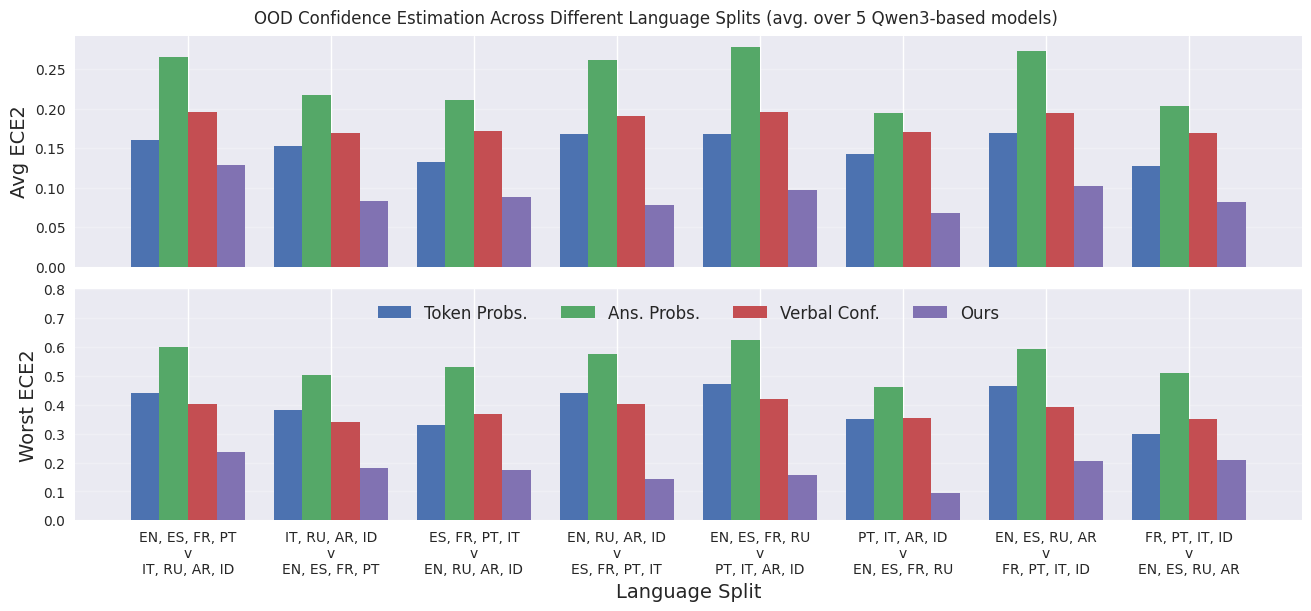

In [20]:
methods = ["logprob", "ans_logprob", "verbal_conf", OUR_METHOD]

fig, axes = plot_avg_worst_by_langsplit(
    full_df,
    methods,
    title="OOD Confidence Estimation Across Different Language Splits (avg. over 5 Qwen3-based models)",
    rotate_xticks=0,
    show_values=False,
    figsize=(13, 6),
    target_metric="ECE2"
)
plt.savefig("../plots/polymath_ood.png", dpi=600, bbox_inches="tight")
plt.show()